# Lab 2A – CNN with Different Optimization Algorithms

## Aim
Develop a Convolutional Neural Network (CNN) model and conduct a comparative experimental study using **SGD, Adam, and RMSProp**, analyze convergence behavior by plotting **loss versus epochs**, and interpret the impact of adaptive learning strategies on training efficiency and model performance.

## Objective

Train the same CNN architecture three times using different optimizers and compare their training behavior.

**Experiment:** CNN + SGD → CNN + Adam → CNN + RMSProp

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Load and Prepare the MNIST Dataset

MNIST contains grayscale images of handwritten digits from **0 to 9**. The images are normalized to the range 0–1.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add the channel dimension required by CNNs
x_train = x_train[..., None]
x_test = x_test[..., None]

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


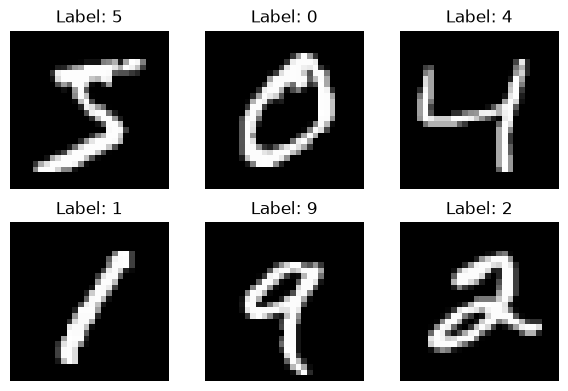

In [3]:
plt.figure(figsize=(6, 4))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Define the CNN Model

We use the **same CNN architecture** for every experiment so that the optimizer is the main variable being compared.

In [4]:
def create_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    return model

# Display the architecture
create_cnn().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training Function

This function creates a fresh CNN, assigns the selected optimizer, trains it, and evaluates it on the test set.

In [5]:
def train_model(optimizer, optimizer_name, epochs=10):
    model = create_cnn()

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"\nTraining with {optimizer_name}...")

    history = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    print(f"{optimizer_name} - Test Loss: {test_loss:.4f}")
    print(f"{optimizer_name} - Test Accuracy: {test_accuracy:.4f}")

    return model, history, test_loss, test_accuracy

## 4. CNN with SGD

**SGD (Stochastic Gradient Descent)** updates model weights using the gradient calculated from batches of training data.

In [6]:
sgd_model, sgd_history, sgd_test_loss, sgd_test_accuracy = train_model(
    tf.keras.optimizers.SGD(learning_rate=0.01),
    "SGD"
)


Training with SGD...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5871 - loss: 1.4751 - val_accuracy: 0.8797 - val_loss: 0.4226
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8908 - loss: 0.3657 - val_accuracy: 0.9378 - val_loss: 0.2267
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9218 - loss: 0.2599 - val_accuracy: 0.9348 - val_loss: 0.2099
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9386 - loss: 0.2043 - val_accuracy: 0.9533 - val_loss: 0.1614
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9493 - loss: 0.1687 - val_accuracy: 0.9670 - val_loss: 0.1261
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9569 - loss: 0.1441 - val_accuracy: 0.9708 - val_loss: 0.1095
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9625 - loss: 0.1270 - val_accuracy: 0.9737 - val_loss: 0.1027
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9665 - l

## 5. CNN with Adam

**Adam** uses adaptive learning rates for individual parameters and combines ideas from momentum and adaptive gradient methods.

In [7]:
adam_model, adam_history, adam_test_loss, adam_test_accuracy = train_model(
    tf.keras.optimizers.Adam(learning_rate=0.001),
    "Adam"
)


Training with Adam...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9294 - loss: 0.2422 - val_accuracy: 0.9775 - val_loss: 0.0767
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9784 - loss: 0.0690 - val_accuracy: 0.9855 - val_loss: 0.0516
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9852 - loss: 0.0494 - val_accuracy: 0.9840 - val_loss: 0.0512
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9887 - loss: 0.0377 - val_accuracy: 0.9875 - val_loss: 0.0450
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9903 - loss: 0.0307 - val_accuracy: 0.9902 - val_loss: 0.0383
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9917 - loss: 0.0267 - val_accuracy: 0.9892 - val_loss: 0.0400
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9929 - loss: 0.0216 - val_accuracy: 0.9903 - val_loss: 0.0336
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9946 - 

## 6. CNN with RMSProp

**RMSProp** adapts the learning rate based on recent squared gradients, helping the model adjust its updates during training.

In [8]:
rmsprop_model, rmsprop_history, rmsprop_test_loss, rmsprop_test_accuracy = train_model(
    tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "RMSProp"
)


Training with RMSProp...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9227 - loss: 0.2545 - val_accuracy: 0.9788 - val_loss: 0.0708
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9785 - loss: 0.0698 - val_accuracy: 0.9830 - val_loss: 0.0588
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9856 - loss: 0.0465 - val_accuracy: 0.9868 - val_loss: 0.0414
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9890 - loss: 0.0349 - val_accuracy: 0.9870 - val_loss: 0.0411
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9919 - loss: 0.0262 - val_accuracy: 0.9892 - val_loss: 0.0400
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9932 - loss: 0.0216 - val_accuracy: 0.9875 - val_loss: 0.0413
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9946 - loss: 0.0177 - val_accuracy: 0.9893 - val_loss: 0.0409
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9958

## 7. Compare Convergence Behavior

The loss-versus-epoch graph shows how quickly and smoothly each optimizer reduces the training loss.

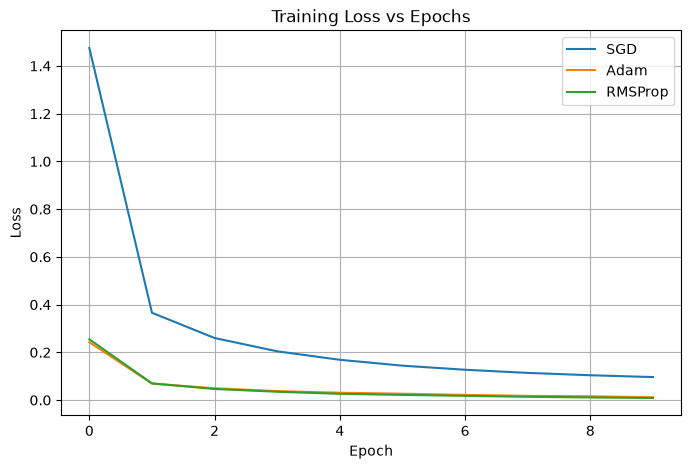

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(sgd_history.history["loss"], label="SGD")
plt.plot(adam_history.history["loss"], label="Adam")
plt.plot(rmsprop_history.history["loss"], label="RMSProp")

plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 8. Compare Validation Loss

Validation loss shows how the models perform on data that was not used directly for weight updates.

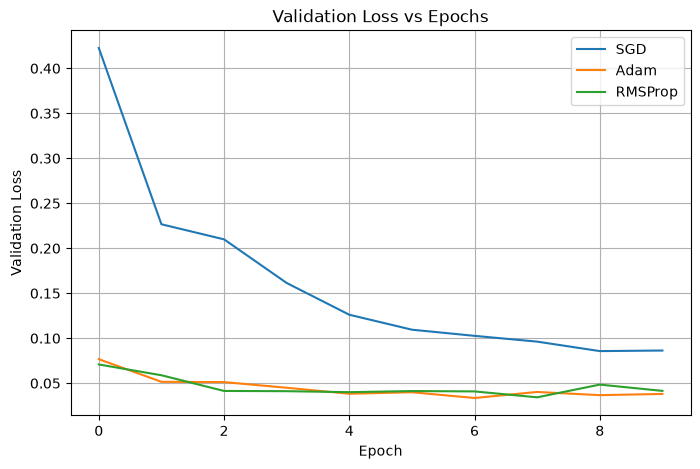

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(sgd_history.history["val_loss"], label="SGD")
plt.plot(adam_history.history["val_loss"], label="Adam")
plt.plot(rmsprop_history.history["val_loss"], label="RMSProp")

plt.title("Validation Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 9. Compare Final Performance

The following table compares the final test loss and test accuracy of the three trained models.

In [11]:
results = {
    "Optimizer": ["SGD", "Adam", "RMSProp"],
    "Test Loss": [sgd_test_loss, adam_test_loss, rmsprop_test_loss],
    "Test Accuracy": [sgd_test_accuracy, adam_test_accuracy, rmsprop_test_accuracy]
}

results_df = __import__("pandas").DataFrame(results)
results_df

,Optimizer,Test Loss,Test Accuracy
0,SGD,0.085725,0.9750
1,Adam,0.032134,0.9896
2,RMSProp,0.038225,0.9902


## 10. Interpretation

- **SGD** uses a fixed learning rate and may require more careful tuning.
- **Adam** adapts the learning rate for different parameters and often converges quickly.
- **RMSProp** also uses adaptive learning rates and can provide efficient convergence.
- The loss-versus-epoch plots help identify which optimizer reaches a low loss faster and how smoothly it converges.
- Final test accuracy and loss show the effect of the optimizer on model performance.

**Important:** The actual best optimizer should be determined from the results produced when the notebook is run, rather than assumed beforehand.

## 11. Analysis Questions

1. What is the role of an optimizer in training a CNN?
2. What is the main difference between SGD and adaptive optimizers?
3. Which optimizer converged faster in this experiment?
4. Which optimizer achieved the lowest final training loss?
5. Which optimizer achieved the best test accuracy?
6. Why can adaptive learning-rate methods improve training efficiency?
7. What does a decreasing loss curve indicate?
8. Why should the same CNN architecture be used when comparing optimizers?

## Conclusion

A CNN was trained using **SGD, Adam, and RMSProp**. Their convergence behavior was compared using loss-versus-epoch plots, and their final test performance was compared using loss and accuracy. The experiment demonstrates how the choice of optimizer can affect **training efficiency, convergence, and model performance**.